# 03 ML Classifiers

Train leakage-fixed machine-learning classifiers for next-day direction. The neural-network model is a feed-forward `MLPClassifier`, not a recurrent model. Feature scaling is handled by sklearn pipelines, so `StandardScaler` is fitted on the training split only and then reused for the test split.

In [1]:
# Project configuration and reproducibility
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    SEED,
    START_DATE,
    END_DATE,
    TRAIN_END_DATE,
    TICKERS,
    CACHE_DIR,
    RESULTS_DIR,
    CHARTS_DIR,
    TRANSACTION_COST,
    set_global_seed,
    ensure_directories,
)

set_global_seed(SEED)
ensure_directories()
print(f"Configured {len(TICKERS)} US/UK indices from {START_DATE} to {END_DATE} with seed={SEED}.")


Configured 7 US/UK indices from 2013-01-01 to 2023-01-01 with seed=42.


## Build execution note

These notebooks were rebuilt from scratch with clean metadata and empty outputs. Live data execution was not completed during repository build because the sandbox could not resolve Yahoo Finance hosts. After installing `requirements.txt` in a normal networked environment, run the notebooks in order from `01_data.ipynb` to `04_combined_model.ipynb`.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.backtest import apply_backtest, save_results_table, summarize_backtest
from src.signals import indicator_features, safe_ml_feature_columns

plt.style.use("seaborn-v0_8-whitegrid")


In [3]:
def load_cached_data() -> dict[str, pd.DataFrame]:
    import re

    frames = {}
    for name, symbol in TICKERS.items():
        cache_path = CACHE_DIR / (re.sub(r"[^A-Za-z0-9]+", "_", symbol).strip("_") + ".csv")
        if cache_path.exists():
            frames[name] = pd.read_csv(cache_path, index_col=0, parse_dates=True)
    if not frames:
        raise FileNotFoundError("No cached data found. Run notebooks/01_data.ipynb first.")
    return frames

price_data = load_cached_data()
print(f"Loaded {len(price_data)} cached US/UK indices.")


Loaded 7 cached US/UK indices.


In [4]:
def make_models() -> dict[str, Pipeline]:
    return {
        "Logistic Regression": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
            ]
        ),
        "Random Forest": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model", RandomForestClassifier(n_estimators=200, max_depth=4, random_state=SEED)),
            ]
        ),
        "Feed-forward neural network": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                (
                    "model",
                    MLPClassifier(
                        hidden_layer_sizes=(32, 16),
                        activation="relu",
                        alpha=0.001,
                        learning_rate_init=0.001,
                        max_iter=500,
                        early_stopping=True,
                        random_state=SEED,
                    ),
                ),
            ]
        ),
    }


In [5]:
rows = []
metric_rows = []
model_backtests = {}
for index_name, frame in price_data.items():
    features = indicator_features(frame)
    model_frame = frame.join(features).dropna()
    feature_cols = [column for column in safe_ml_feature_columns(model_frame) if column in features.columns]
    forbidden = {"direction", "returns", "strategy_return", "gross_strategy_return", "net_strategy_return"}
    assert forbidden.isdisjoint(feature_cols), f"Leakage columns found: {forbidden.intersection(feature_cols)}"

    split_date = pd.Timestamp(TRAIN_END_DATE)
    train = model_frame.loc[model_frame.index <= split_date]
    test = model_frame.loc[model_frame.index > split_date]

    if train.empty or test.empty:
        raise ValueError(f"Insufficient train/test data for {index_name}.")

    X_train = train[feature_cols]
    y_train = train["direction"].astype(int)
    X_test = test[feature_cols]
    y_test = test["direction"].astype(int)

    for model_name, pipeline in make_models().items():
        pipeline.fit(X_train, y_train)
        pred = pipeline.predict(X_test)
        signal = pd.Series(pred, index=X_test.index, name=model_name)
        bt_frame = apply_backtest(frame.loc[X_test.index], signal, cost=TRANSACTION_COST)
        rows.append(summarize_backtest(index_name, model_name, bt_frame))
        metric_rows.append(
            {
                "index": index_name,
                "model": model_name,
                "accuracy": accuracy_score(y_test, pred),
                "balanced_accuracy": balanced_accuracy_score(y_test, pred),
                "train_rows": len(train),
                "test_rows": len(test),
                "n_features": len(feature_cols),
            }
        )
        model_backtests[(index_name, model_name)] = bt_frame

ml_results = save_results_table(rows, RESULTS_DIR / "ml_results.csv")
ml_metrics = pd.DataFrame(metric_rows)
ml_metrics.to_csv(RESULTS_DIR / "ml_classification_metrics.csv", index=False)
ml_metrics.sort_values("balanced_accuracy", ascending=False).head(15)


,index,model,accuracy,balanced_accuracy,train_rows,test_rows,n_features
5,Dow Jones Industrial Average,Feed-forward neural network,0.550993,0.538539,1712,755,16
16,Cboe UK 100,Random Forest,0.539683,0.532997,1723,756,16
18,Cboe Volatility Index,Logistic Regression,0.581457,0.525986,1712,755,16
20,Cboe Volatility Index,Feed-forward neural network,0.564238,0.522147,1712,755,16
19,Cboe Volatility Index,Random Forest,0.570861,0.514174,1712,755,16
10,Russell 2000,Random Forest,0.523179,0.512118,1712,755,16
6,NASDAQ Composite,Logistic Regression,0.495364,0.511545,1712,755,16
9,Russell 2000,Logistic Regression,0.520530,0.510695,1712,755,16
11,Russell 2000,Feed-forward neural network,0.517881,0.509712,1712,755,16
15,Cboe UK 100,Logistic Regression,0.506614,0.508764,1723,756,16


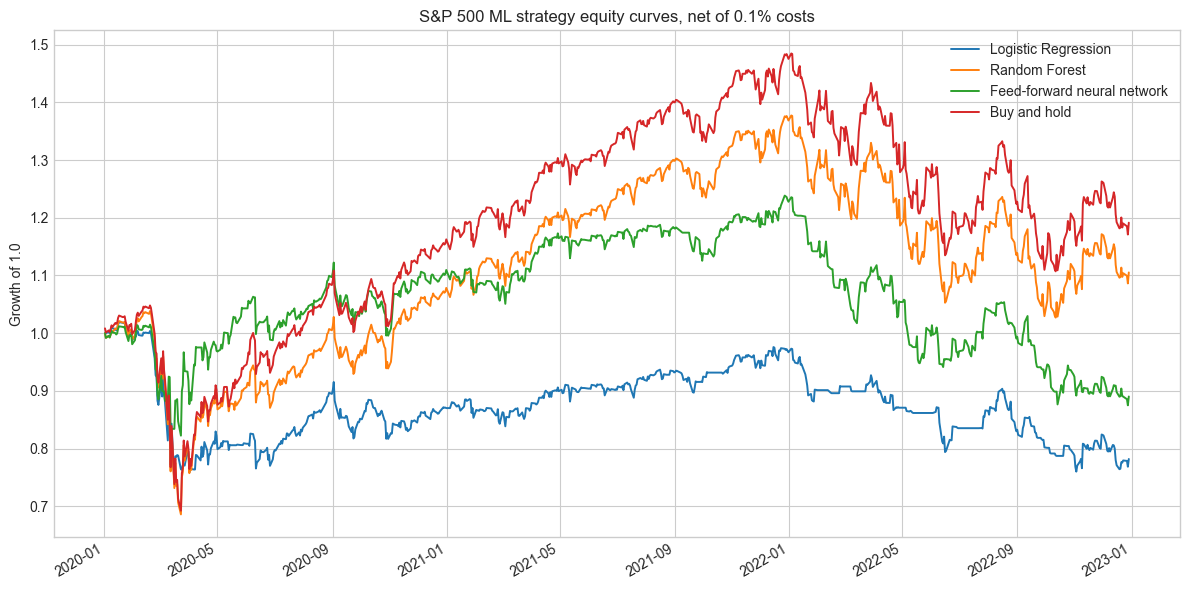

In [6]:
sp500_curves = []
for (index_name, model_name), result in model_backtests.items():
    if index_name == "S&P 500":
        curve = np.exp(result["net_strategy_return"].cumsum())
        curve.name = model_name
        sp500_curves.append(curve)

if sp500_curves:
    equity = pd.concat(sp500_curves, axis=1)
    buy_hold = np.exp(model_backtests[("S&P 500", "Logistic Regression")]["buy_and_hold_return"].cumsum())
    buy_hold.name = "Buy and hold"
    equity = equity.join(buy_hold)

    fig, ax = plt.subplots(figsize=(12, 6))
    equity.plot(ax=ax, linewidth=1.4)
    ax.set_title("S&P 500 ML strategy equity curves, net of 0.1% costs")
    ax.set_ylabel("Growth of 1.0")
    ax.set_xlabel("")
    fig.tight_layout()
    fig.savefig(CHARTS_DIR / "ml_equity_curves_sp500.png", dpi=160)
    plt.show()


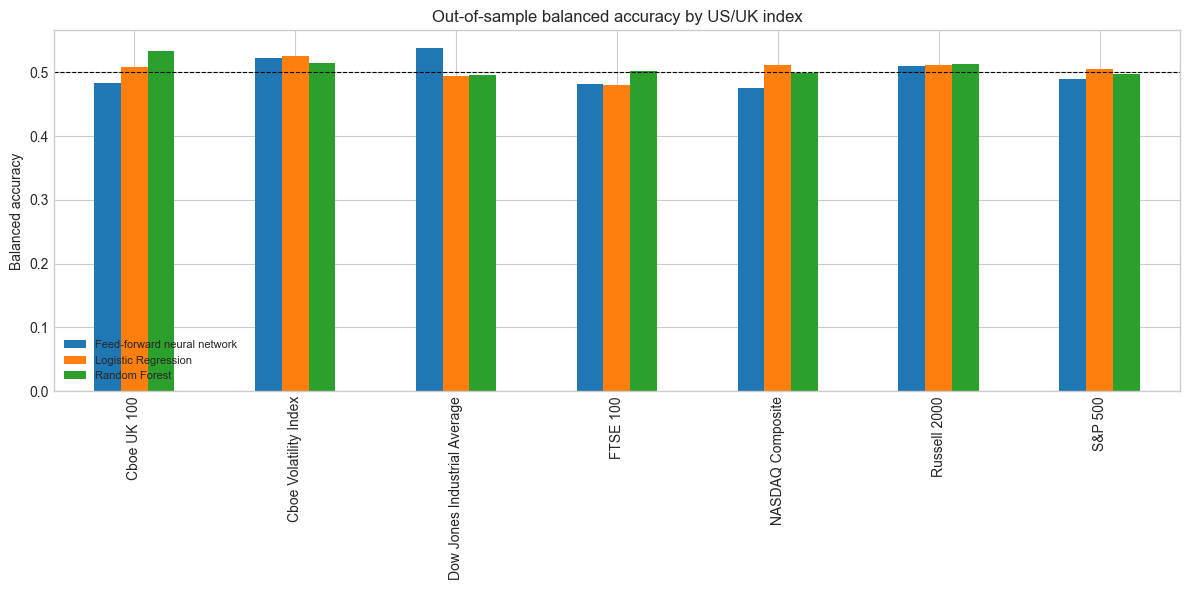

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_data = ml_metrics.pivot(index="index", columns="model", values="balanced_accuracy")
plot_data.plot(kind="bar", ax=ax)
ax.axhline(0.5, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Out-of-sample balanced accuracy by US/UK index")
ax.set_ylabel("Balanced accuracy")
ax.set_xlabel("")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
fig.savefig(CHARTS_DIR / "ml_accuracy_by_index.png", dpi=160)
plt.show()
